In [3]:
import pandas as pd

df_housing = pd.read_csv('D:\\Download\\data-môn ngày thứ 6\\archive1\\house_buying_dec29th_2025.csv')
print(df_housing.shape)
df_housing.info()
df_housing.head()


(66912, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66912 entries, 0 to 66911
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 66912 non-null  int64  
 1   detail_url         66905 non-null  object 
 2   title              66912 non-null  object 
 3   location           66912 non-null  object 
 4   timeline_hours     66912 non-null  int64  
 5   area_m2            50344 non-null  float64
 6   bedrooms           55273 non-null  float64
 7   bathrooms          51548 non-null  float64
 8   floors             52278 non-null  float64
 9   frontage           66912 non-null  bool   
 10  price_million_vnd  64809 non-null  float64
dtypes: bool(1), float64(5), int64(2), object(3)
memory usage: 5.2+ MB


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0


In [4]:
import numpy as np
 
# Tách city từ location dạng "Quận/Huyện, Tỉnh/Thành"
df_housing['city'] = df_housing['location'].str.split(',').str[-1].str.strip()
 
# Lọc bỏ giá trị phi lý: giá <= 0 hoặc quá lớn, diện tích quá nhỏ/quá lớn
df_housing = df_housing[
    (df_housing.price_million_vnd > 0) &
    (df_housing.price_million_vnd < 200_000) &
    (df_housing.area_m2 > 5) &
    (df_housing.area_m2 < 1000)
].copy()
 
# Điền khuyết bedrooms/bathrooms/floors bằng median
for c in ['bedrooms', 'bathrooms', 'floors']:
    df_housing[c] = df_housing[c].fillna(df_housing[c].median())
 
df_housing = df_housing.dropna(subset=['area_m2', 'price_million_vnd'])
 
# Gộp các tỉnh/thành hiếm thành 'Other' (giữ lại top 15)
top_cities = df_housing['city'].value_counts().head(15).index
df_housing['city_grp'] = df_housing['city'].where(df_housing['city'].isin(top_cities), 'Other')
 
print('Số dòng sau làm sạch:', len(df_housing))


Số dòng sau làm sạch: 49105


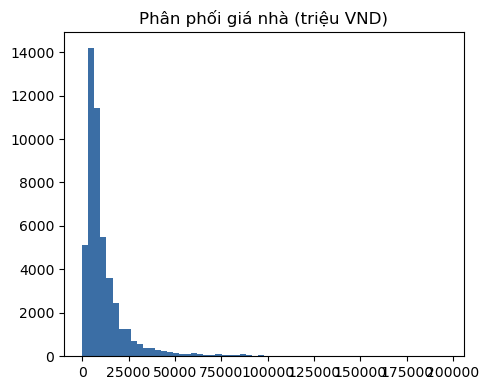

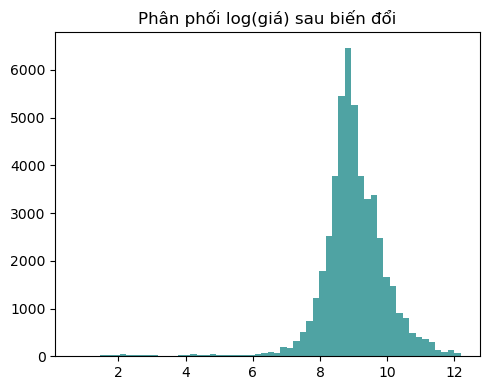

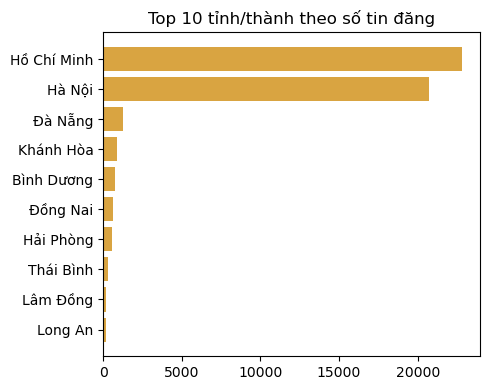

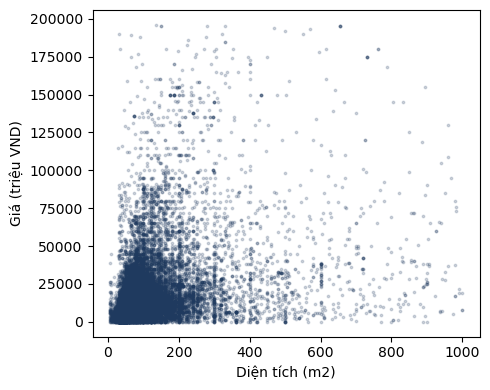

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Hình 4.5 / 4.6 - Phân phối giá gốc và log(giá)
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(df_housing['price_million_vnd'], bins=60, color='#3b6ea5')
ax.set_title('Phân phối giá nhà (triệu VND)')
plt.tight_layout(); plt.savefig('h_price_hist.png')
 
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(np.log1p(df_housing['price_million_vnd']), bins=60, color='#4fa3a3')
ax.set_title('Phân phối log(giá) sau biến đổi')
plt.tight_layout(); plt.savefig('h_price_log_hist.png')
 
# Hình 4.7 - Top 10 tỉnh/thành
fig, ax = plt.subplots(figsize=(5,4))
top10 = df_housing['city'].value_counts().head(10)
ax.barh(top10.index[::-1], top10.values[::-1], color='#d9a441')
ax.set_title('Top 10 tỉnh/thành theo số tin đăng')
plt.tight_layout(); plt.savefig('h_top_city.png')
 
# Hình 4.8 - Diện tích vs Giá
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(df_housing['area_m2'], df_housing['price_million_vnd'], s=3, alpha=0.2, color='#1f3a5f')
ax.set_xlabel('Diện tích (m2)'); ax.set_ylabel('Giá (triệu VND)')
plt.tight_layout(); plt.savefig('h_area_price_scatter.png')


In [9]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----- Housing (hồi quy trên log giá) -----
num_feats_h = ['area_m2', 'bedrooms', 'bathrooms', 'floors']
bin_feats_h = ['frontage']
cat_feats_h = ['city_grp']

Xh = df_housing[num_feats_h + bin_feats_h + cat_feats_h]
yh = np.log1p(df_housing['price_million_vnd'])

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, random_state=42
)

preprocess_housing = ColumnTransformer(
    [
        ('num', StandardScaler(), num_feats_h),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', drop='first'),
            cat_feats_h,
        ),
    ],
    remainder='passthrough',
)

In [11]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline  # Bổ sung import Pipeline
from sklearn.tree import DecisionTreeRegressor


def make_regressors():
  return {
      'Linear Regression': LinearRegression(),
      'Ridge Regression': Ridge(alpha=1.0),
      'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
      'Random Forest': RandomForestRegressor(
          n_estimators=200, max_depth=14, random_state=42, n_jobs=-1
      ),
      'Gradient Boosting': GradientBoostingRegressor(
          n_estimators=200, max_depth=3, random_state=42
      ),
  }


# Housing
fitted_reg_h = {}
for name, reg in make_regressors().items():
  pipe = Pipeline([('pre', preprocess_housing), ('reg', reg)])
  pipe.fit(Xh_train, yh_train)
  fitted_reg_h[name] = pipe

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
results_reg_h = {}
for name, pipe in fitted_reg_h.items():
    yp = pipe.predict(Xh_test)
    y_true_vnd, y_pred_vnd = np.expm1(yh_test), np.expm1(yp)
    results_reg_h[name] = {
        'MAE_log':  mean_absolute_error(yh_test, yp),
        'RMSE_log': np.sqrt(mean_squared_error(yh_test, yp)),
        'R2_log':   r2_score(yh_test, yp),
        'MAE_trieu_vnd': mean_absolute_error(y_true_vnd, y_pred_vnd),
    }
 
pd.DataFrame(results_reg_h).T.round(4).sort_values('R2_log', ascending=False)


,MAE_log,RMSE_log,R2_log,MAE_trieu_vnd
Gradient Boosting,0.4417,0.8270,0.3994,5138.7315
Random Forest,0.4409,0.8286,0.3971,5080.9689
Decision Tree,0.4696,0.8837,0.3142,5458.1558
Linear Regression,0.5166,0.8961,0.2948,10653.1947
Ridge Regression,0.5166,0.8961,0.2948,10653.5045
